In [173]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, f1_score

In [174]:
loan_df = pd.read_csv('loan_data.csv')
print(loan_df.info())
print(loan_df.describe())
print(loan_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [175]:
# 1. Data Cleaning & EDA
num_cols = loan_df.select_dtypes(include='number').columns
cat_cols = loan_df.select_dtypes(include='object').columns

In [176]:
num_imp = SimpleImputer(strategy='mean')
loan_df[num_cols] = num_imp.fit_transform(loan_df[num_cols])
cat_imp = SimpleImputer(strategy='most_frequent')
loan_df[cat_cols] = cat_imp.fit_transform(loan_df[cat_cols])

In [177]:
loan_df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

Text(0.5, 1.0, 'Is Loan Approved or not')

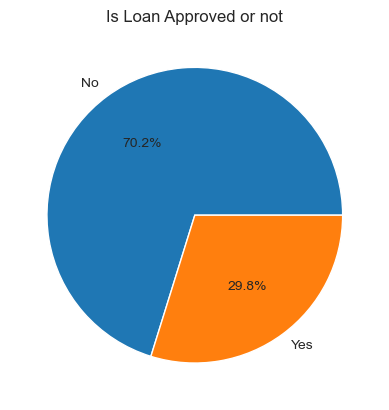

In [178]:
class_count = loan_df['Loan_Approved'].value_counts()
plt.pie(class_count, labels=['No','Yes'], autopct='%1.1f%%')
plt.title('Is Loan Approved or not')

[Text(0, 0, '722'), Text(0, 0, '278')]

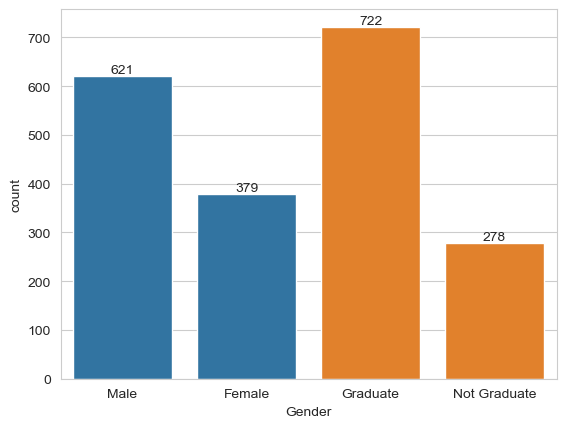

In [179]:
gender_count = loan_df['Gender'].value_counts()
ax = sns.barplot(gender_count)
ax.bar_label(ax.containers[0])

edu_cnt = loan_df['Education_Level'].value_counts()
ax = sns.barplot(edu_cnt)
ax.bar_label(ax.containers[1])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

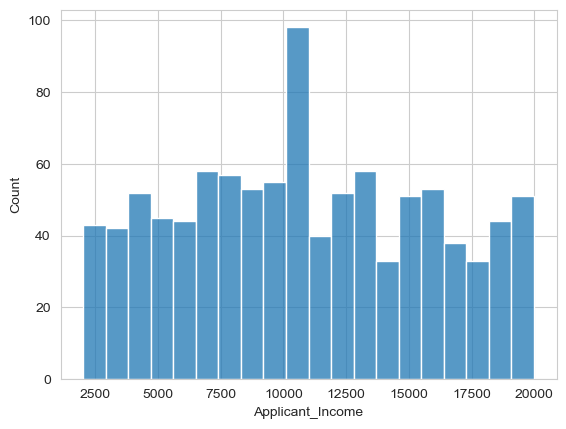

In [180]:
sns.histplot(
    data = loan_df,
    x = 'Applicant_Income',
    bins = 20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

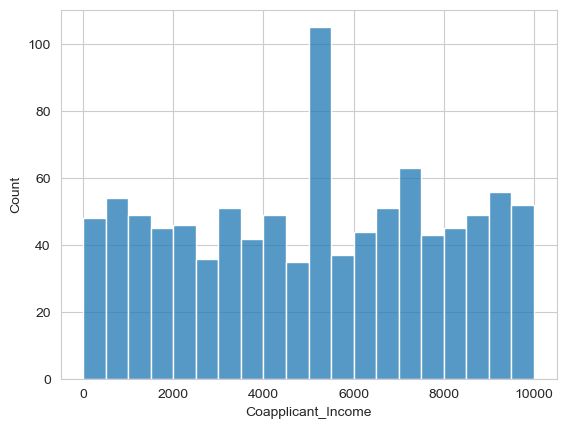

In [181]:
sns.histplot(
    data=loan_df,
    x='Coapplicant_Income',
    bins=20
)

<Axes: xlabel='Credit_Score', ylabel='Count'>

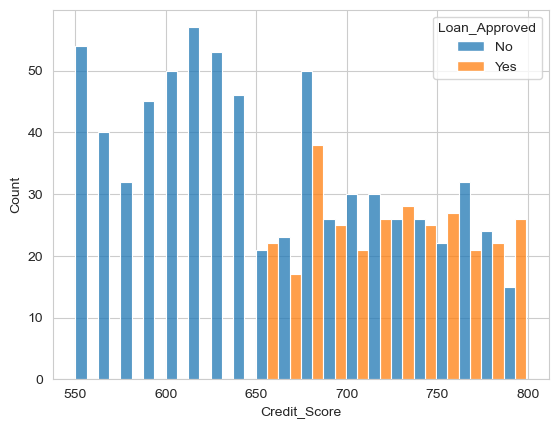

In [182]:
sns.histplot(
    data=loan_df,
    x='Credit_Score',
    hue='Loan_Approved',
    bins=20,
    multiple='dodge'
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

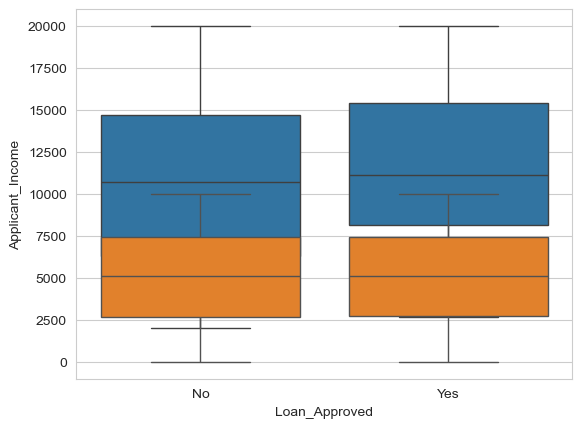

In [183]:
sns.boxplot(
    data=loan_df,
    x='Loan_Approved',
    y='Applicant_Income'
)
sns.boxplot(
    data=loan_df,
    x='Loan_Approved',
    y='Coapplicant_Income'
)

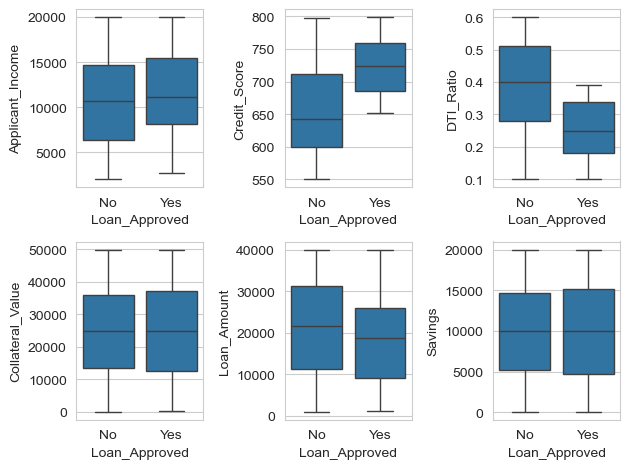

In [184]:
fig, axes = plt.subplots(2,3)
sns.boxplot(ax=axes[0, 0], data=loan_df, x='Loan_Approved', y='Applicant_Income')
sns.boxplot(ax=axes[0,1], data=loan_df, x='Loan_Approved', y='Credit_Score')
sns.boxplot(ax=axes[0,2], data=loan_df, x='Loan_Approved', y='DTI_Ratio')
sns.boxplot(ax=axes[1,0], data=loan_df, x='Loan_Approved', y='Collateral_Value')
sns.boxplot(ax=axes[1,1], data=loan_df, x='Loan_Approved', y='Loan_Amount')
sns.boxplot(ax=axes[1,2], data=loan_df, x='Loan_Approved', y='Savings')
plt.tight_layout()

In [185]:
loan_df.drop(columns='Applicant_ID', inplace=True)
loan_df.columns
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

In [186]:
le = LabelEncoder()
loan_df['Education_Level'] = le.fit_transform(loan_df['Education_Level'])
loan_df['Loan_Approved'] = le.fit_transform(loan_df['Loan_Approved'])

cols = ['Employment_Status','Marital_Status','Loan_Purpose','Property_Area','Gender','Employer_Category']
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
encoded = ohe.fit_transform(loan_df[cols])
encoded
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(), index=loan_df.index)
encoded_df.head()
loan_df = pd.concat([loan_df.drop(columns=cols), encoded_df], axis=1)

<Axes: >

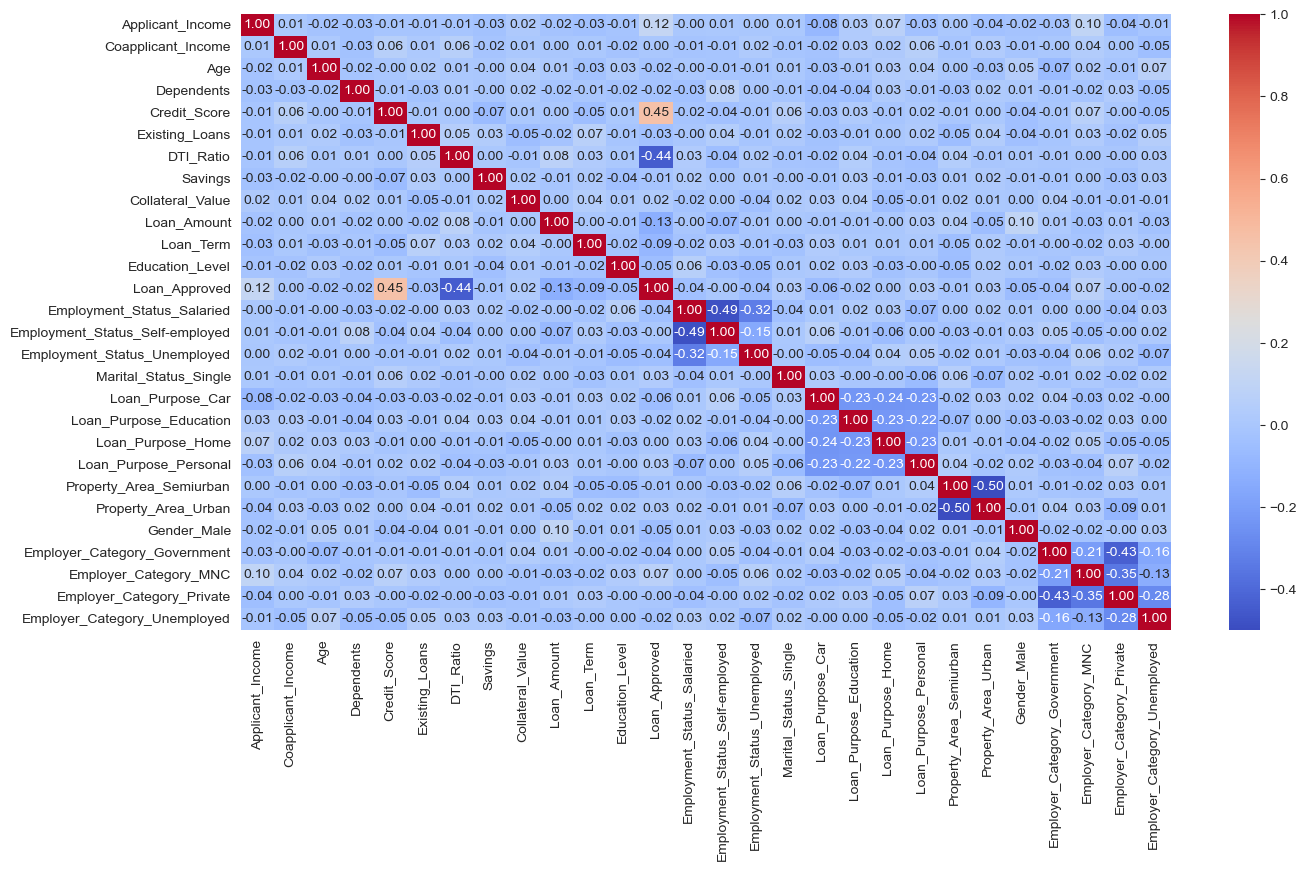

In [187]:
num_cols = loan_df.select_dtypes(include='number')
corr_matrix = num_cols.corr()

plt.figure(figsize=(15,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

In [188]:
corr_matrix['Loan_Approved'].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

In [ ]:
# 2. Feature Engineering

loan_df["DTI_Ratio_sq"] = loan_df['DTI_Ratio'] ** 2
loan_df['Credit_Score_sq'] = loan_df['Credit_Score'] ** 2

X = loan_df.drop(columns=['Loan_Approved', 'Credit_Score', 'DTI_Ratio'])
y = loan_df['Loan_Approved']

# 3. Model Training (Logistic, KNN, NB)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [190]:
# Logistic Regression Model

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print('--- Logistic Regression Model Results ---')
print(f'Precision : {precision_score(y_test, y_pred): .2}')
print(f'Recall : {recall_score(y_test, y_pred): .2}')
print(f'f1 score : {f1_score(y_test, y_pred): .2}')
print(f'CM: {confusion_matrix(y_test, y_pred)} ')
print(f'Accuracy : {accuracy_score(y_test, y_pred): .2}')

--- Logistic Regression Model Results ---
Precision :  0.79
Recall :  0.8
f1 score :  0.8
CM: [[126  13]
 [ 12  49]] 
Accuracy :  0.88


In [191]:
# KNN Model

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print('--- KNN Model Results ---')
print(f'Precision : {precision_score(y_test, y_pred): .2}')
print(f'Recall : {recall_score(y_test, y_pred): .2}')
print(f'f1 score : {f1_score(y_test, y_pred): .2}')
print(f'CM : {confusion_matrix(y_test, y_pred)}')
print(f'Accuracy : {accuracy_score(y_test, y_pred): .2}')

--- KNN Model Results ---
Precision :  0.62
Recall :  0.51
f1 score :  0.56
CM : [[120  19]
 [ 30  31]]
Accuracy :  0.76


In [192]:
# GaussianNB Model

model = GaussianNB()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print('--- GaussianNB Model Results ---')
print(f'Precision : {precision_score(y_test, y_pred): .2}')
print(f'Recall : {recall_score(y_test, y_pred): .2}')
print(f'f1 score : {f1_score(y_test, y_pred): .2}')
print(f'CM : {confusion_matrix(y_test, y_pred)}')
print(f'Accuracy : {accuracy_score(y_test, y_pred): .2}')

--- GaussianNB Model Results ---
Precision :  0.78
Recall :  0.77
f1 score :  0.78
CM : [[126  13]
 [ 14  47]]
Accuracy :  0.86


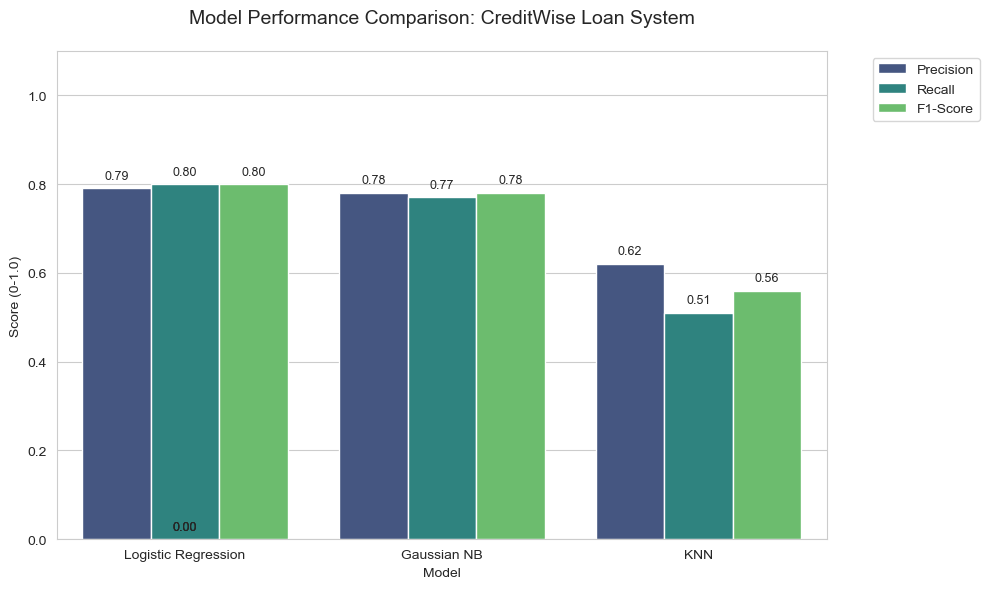

In [ ]:
# 4. Model Performance Comparison

data = {
    'Model': ['Logistic Regression', 'Gaussian NB', 'KNN'],
    'Precision': [0.79, 0.78, 0.62],
    'Recall': [0.80, 0.77, 0.51],
    'F1-Score': [0.8, 0.78, 0.56]
}

df_plot = pd.DataFrame(data)

df_melted = df_plot.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric', palette='viridis')

plt.title('Model Performance Comparison: CreditWise Loan System', fontsize=14, pad=20)
plt.ylim(0, 1.1) 
plt.ylabel('Score (0-1.0)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300)
plt.show()